# Project Overview: Binary Classification with a Tabular Employee Attrition Dataset
**Objective:** To predict employee attrition using machine learning techniques, focusing on addressing class imbalance and optimizing model performance to achieve high predictive accuracy on unseen data.

## 1. Libraries & Workspace Setup

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s3e3')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s3e3


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import joblib

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e3/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s3e3/test.csv')

In [5]:
train_df.head()

,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,...,80,1,10,2,3,10,0,7,8,0
1,1,35,Travel_Rarely,921,Sales,8,3,Other,1,1,...,80,1,4,3,3,4,2,0,3,0
2,2,32,Travel_Rarely,718,Sales,26,3,Marketing,1,3,...,80,2,4,3,3,3,2,1,2,0
3,3,38,Travel_Rarely,1488,Research & Development,2,3,Medical,1,3,...,80,0,15,1,1,6,0,0,2,0
4,4,50,Travel_Rarely,1017,Research & Development,5,4,Medical,1,2,...,80,0,31,0,3,31,14,4,10,1


In [6]:
test_df.head()

,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1677,19,Non-Travel,992,Research & Development,1,1,Medical,1,4,...,4,80,0,1,2,2,1,0,0,0
1,1678,45,Travel_Rarely,1136,Sales,4,4,Marketing,1,3,...,3,80,1,7,3,3,2,2,2,2
2,1679,37,Travel_Rarely,155,Research & Development,13,3,Life Sciences,1,4,...,2,80,2,13,2,2,7,7,1,7
3,1680,32,Travel_Rarely,688,Research & Development,1,4,Life Sciences,1,3,...,3,80,0,14,2,2,14,10,11,8
4,1681,29,Travel_Frequently,464,Research & Development,9,1,Life Sciences,1,3,...,1,80,0,1,5,3,1,0,0,0


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1677 entries, 0 to 1676
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1677 non-null   int64 
 1   Age                       1677 non-null   int64 
 2   BusinessTravel            1677 non-null   object
 3   DailyRate                 1677 non-null   int64 
 4   Department                1677 non-null   object
 5   DistanceFromHome          1677 non-null   int64 
 6   Education                 1677 non-null   int64 
 7   EducationField            1677 non-null   object
 8   EmployeeCount             1677 non-null   int64 
 9   EnvironmentSatisfaction   1677 non-null   int64 
 10  Gender                    1677 non-null   object
 11  HourlyRate                1677 non-null   int64 
 12  JobInvolvement            1677 non-null   int64 
 13  JobLevel                  1677 non-null   int64 
 14  JobRole                 

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1119 non-null   int64 
 1   Age                       1119 non-null   int64 
 2   BusinessTravel            1119 non-null   object
 3   DailyRate                 1119 non-null   int64 
 4   Department                1119 non-null   object
 5   DistanceFromHome          1119 non-null   int64 
 6   Education                 1119 non-null   int64 
 7   EducationField            1119 non-null   object
 8   EmployeeCount             1119 non-null   int64 
 9   EnvironmentSatisfaction   1119 non-null   int64 
 10  Gender                    1119 non-null   object
 11  HourlyRate                1119 non-null   int64 
 12  JobInvolvement            1119 non-null   int64 
 13  JobLevel                  1119 non-null   int64 
 14  JobRole                 

In [9]:
train_df.shape

(1677, 35)

In [10]:
test_df.shape

(1119, 34)

In [11]:
train_df.isnull().sum()

id                          0
Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

In [12]:
test_df.isnull().sum()

id                          0
Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithC

## 3. Exploratory Data Analysis

In [13]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1677.0,838.000000,484.252517,0.0,419.0,838.0,1257.0,1676.0
Age,1677.0,36.036971,8.507112,18.0,30.0,35.0,41.0,60.0
DailyRate,1677.0,892.749553,374.496259,107.0,589.0,890.0,1223.0,3921.0
DistanceFromHome,1677.0,8.683959,7.826143,1.0,2.0,7.0,12.0,29.0
Education,1677.0,2.937984,1.039078,1.0,2.0,3.0,4.0,15.0
EmployeeCount,1677.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
EnvironmentSatisfaction,1677.0,2.757901,1.086835,1.0,2.0,3.0,4.0,4.0
HourlyRate,1677.0,67.798450,19.435928,30.0,51.0,69.0,84.0,100.0
JobInvolvement,1677.0,2.782349,0.650664,1.0,2.0,3.0,3.0,4.0
JobLevel,1677.0,1.998807,1.083065,1.0,1.0,2.0,2.0,7.0


In [14]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1119.0,2236.000000,323.171781,1677.0,1956.5,2236.0,2515.5,2795.0
Age,1119.0,36.147453,8.786102,18.0,30.0,35.0,41.0,59.0
DailyRate,1119.0,883.550492,366.427230,6.0,589.0,889.0,1206.0,1499.0
DistanceFromHome,1119.0,8.667560,7.772384,1.0,2.0,7.0,12.0,29.0
Education,1119.0,2.941912,1.012986,1.0,2.0,3.0,4.0,5.0
EmployeeCount,1119.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
EnvironmentSatisfaction,1119.0,2.736372,1.106668,0.0,2.0,3.0,4.0,4.0
HourlyRate,1119.0,68.226095,19.495282,30.0,52.0,71.0,85.0,100.0
JobInvolvement,1119.0,2.741734,0.652751,0.0,2.0,3.0,3.0,4.0
JobLevel,1119.0,1.999106,1.091109,1.0,1.0,2.0,2.0,5.0


/tmp/ipykernel_126/621539880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Attrition', palette='viridis', edgecolor='black')


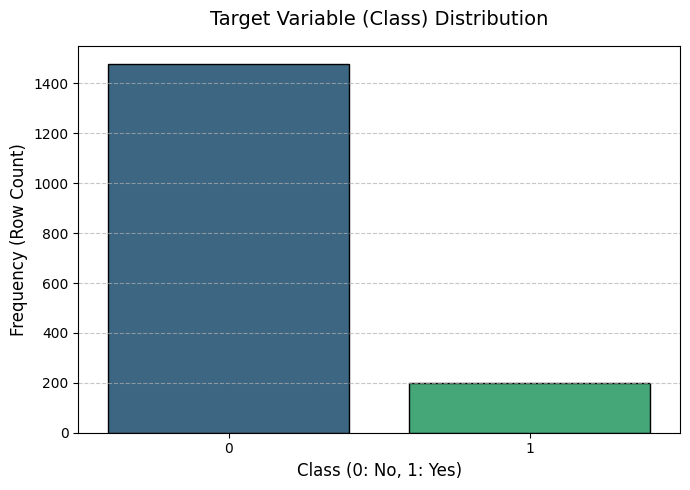

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(data=train_df, x='Attrition', palette='viridis', edgecolor='black')

plt.title('Target Variable (Class) Distribution', fontsize=14, pad=15)
plt.xlabel('Class (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Frequency (Row Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

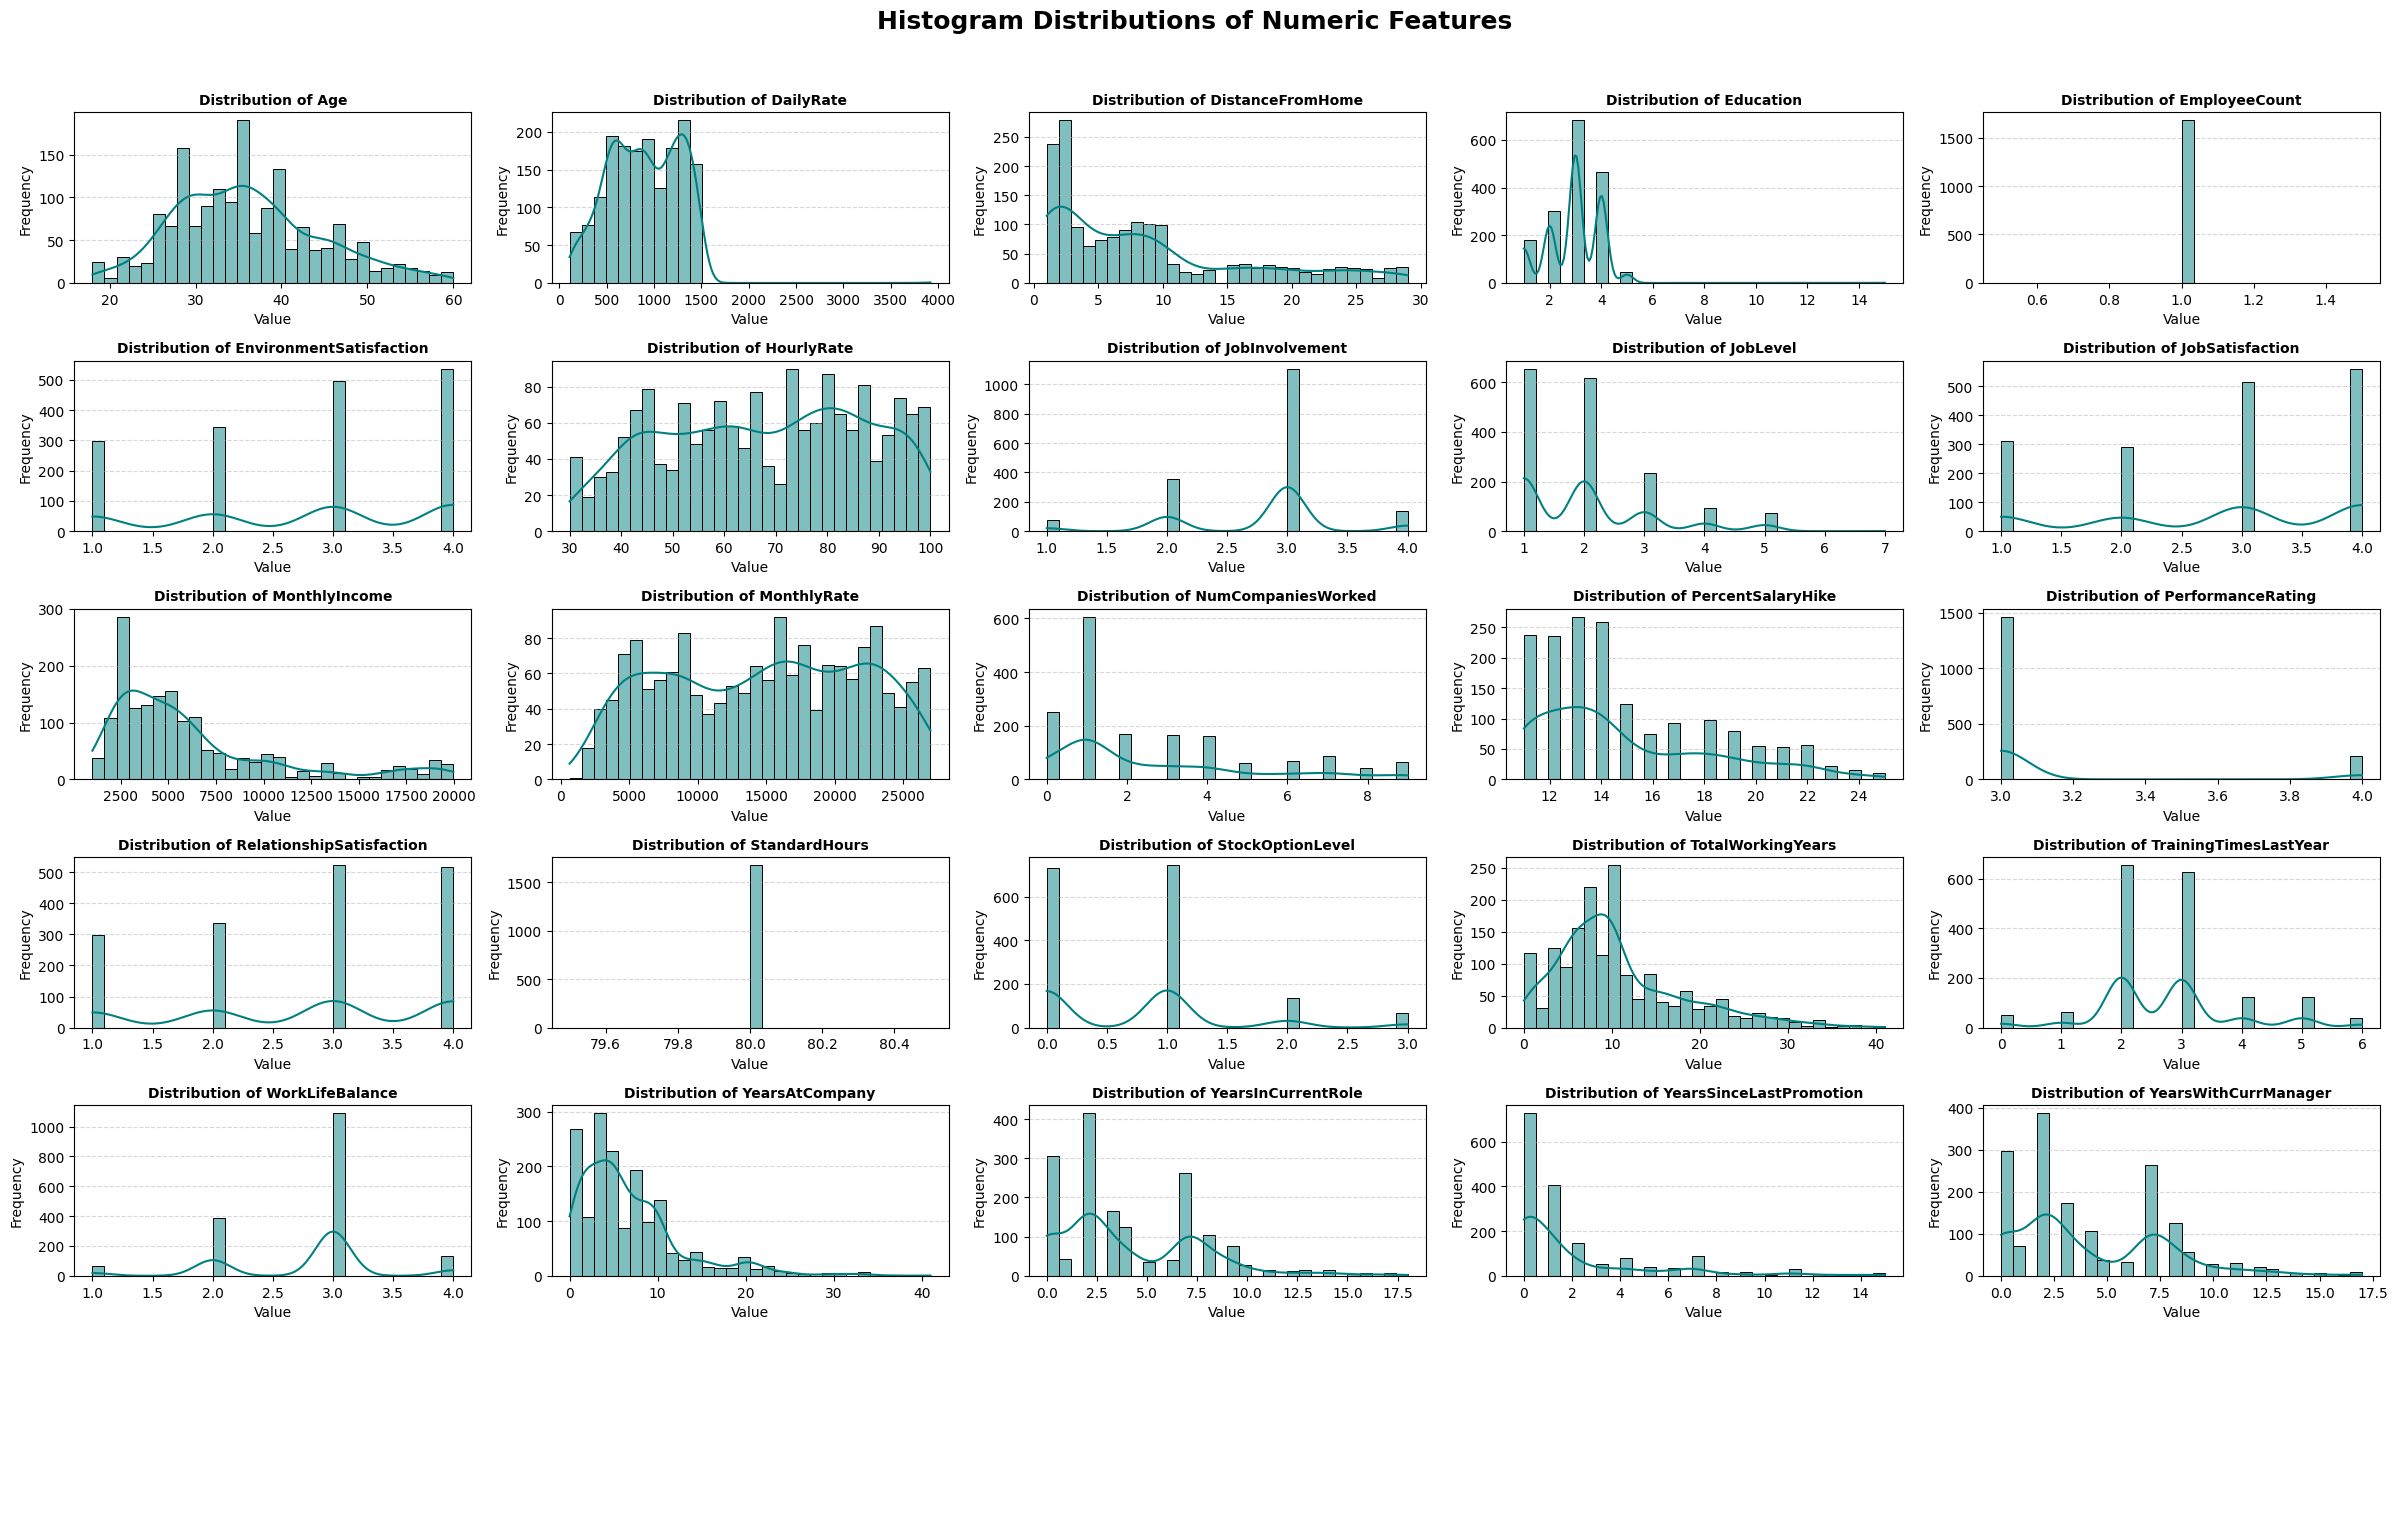

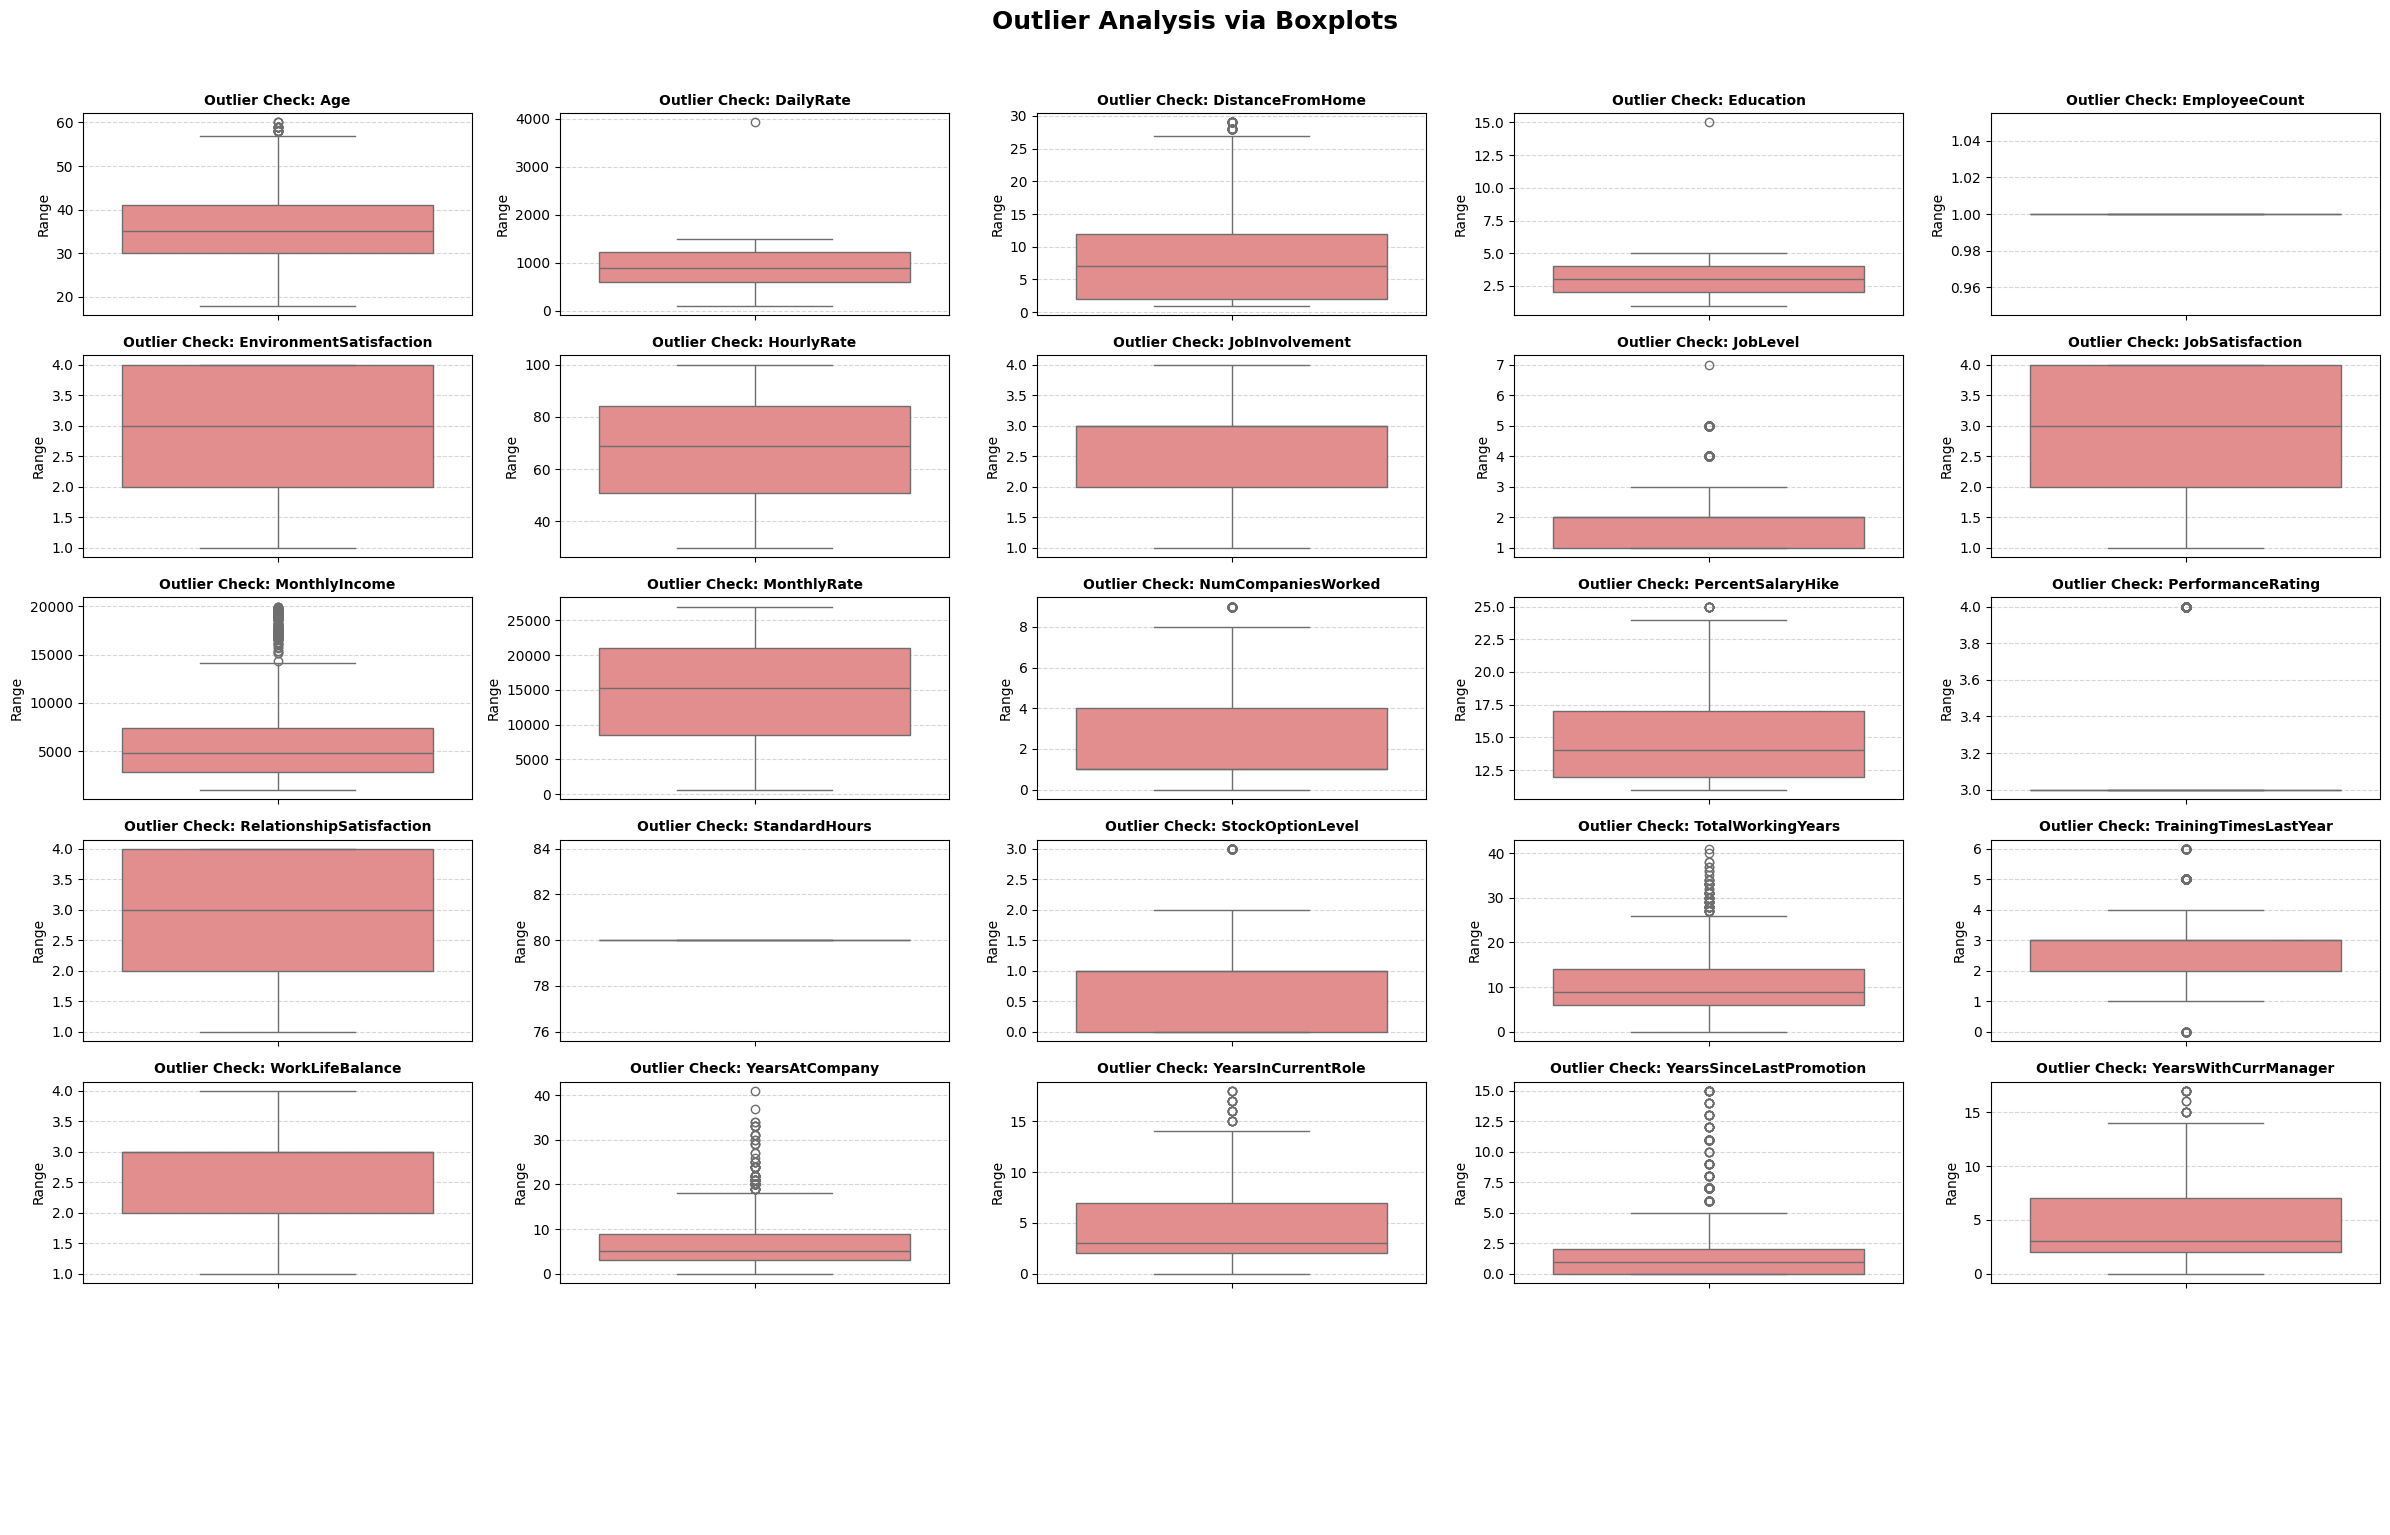

In [16]:
exclude_cols = ['id', 'Attrition']
num_features = [col for col in train_df.select_dtypes(include=['int64']).columns if col not in exclude_cols]

# Histogram
fig, axes = plt.subplots(6, 5, figsize=(24, 15))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Boxplot
fig, axes = plt.subplots(6, 5, figsize=(24, 15))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

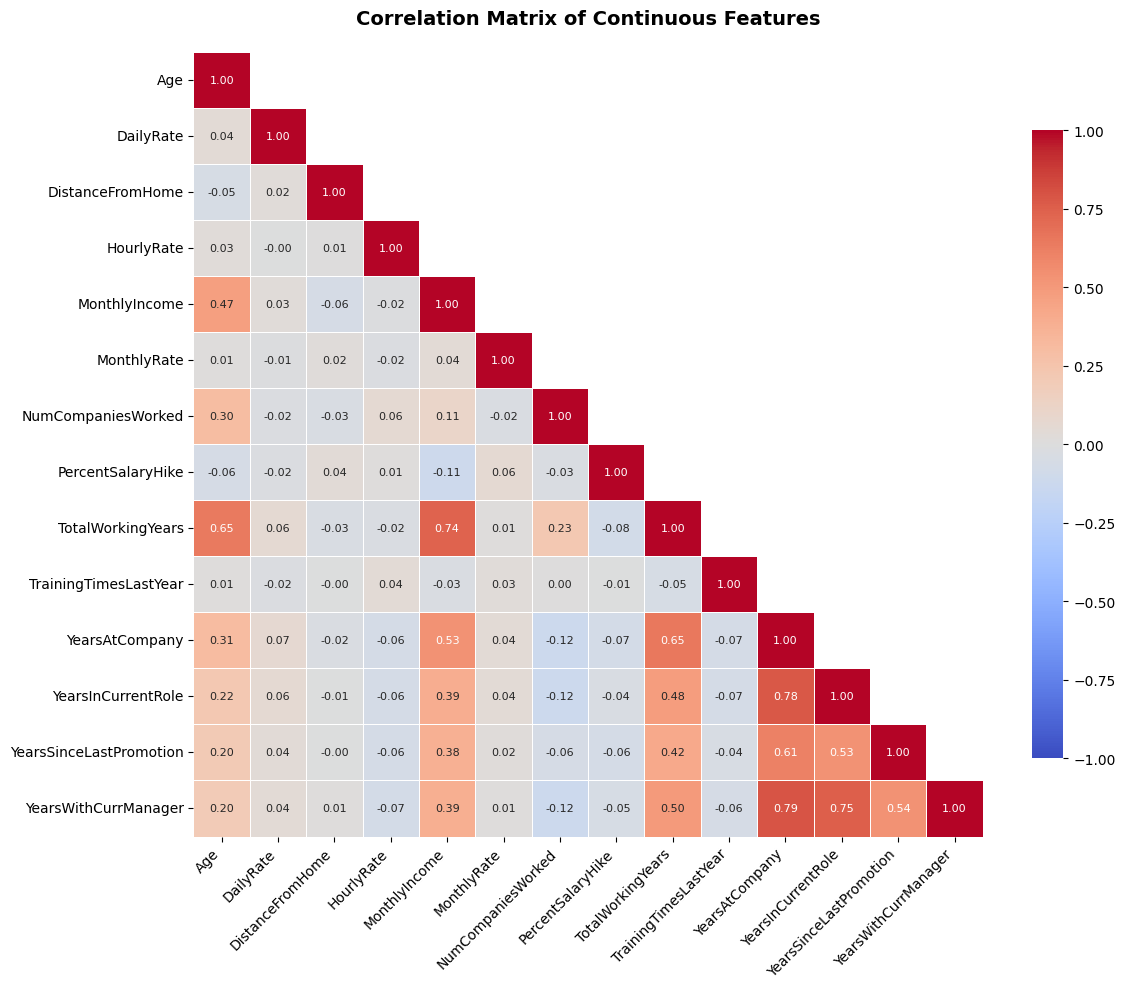

In [17]:
continuous_features = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 
    'YearsWithCurrManager'
]

corr_matrix = train_df[continuous_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title('Correlation Matrix of Continuous Features', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [18]:
train_df = train_df.drop(columns=['EmployeeCount', 'StandardHours'], errors='ignore')
test_df = test_df.drop(columns=['EmployeeCount', 'StandardHours'], errors='ignore')

In [19]:
Q1 = train_df['MonthlyIncome'].quantile(0.25)
Q3 = train_df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

train_df = train_df[(train_df['MonthlyIncome'] >= lower_bound) & 
                    (train_df['MonthlyIncome'] <= upper_bound)]

In [20]:
train_df['LoyaltyRatio'] = np.where(
    train_df['TotalWorkingYears'] > 0, 
    train_df['YearsAtCompany'] / train_df['TotalWorkingYears'], 
    0
)

In [21]:
test_df['LoyaltyRatio'] = np.where(
    test_df['TotalWorkingYears'] > 0, 
    test_df['YearsAtCompany'] / test_df['TotalWorkingYears'], 
    0
)

In [22]:
encoders = {}
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 
            'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

In [23]:
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    encoders[col] = le

for col in cat_cols:
    if col in test_df.columns:
        test_df[col] = encoders[col].transform(test_df[col])

In [24]:
train_df = pd.get_dummies(train_df, columns=['Gender'], drop_first=True)

In [25]:
test_df = pd.get_dummies(test_df, columns=['Gender'], drop_first=True)

In [26]:
x = train_df.drop(columns=['Attrition', 'id'], errors='ignore')
y = train_df['Attrition']

In [27]:
x.shape

(1538, 32)

In [28]:
y.shape

(1538,)

In [29]:
x_test_final = test_df.drop(columns=['id'], errors='ignore')

In [30]:
x_test_final.shape

(1119, 32)

## 5. Model Training, Optimization & Deployment Strategy

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
def algo_test(x, y):
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LogisticRegression()
    sgd = SGDClassifier(loss='log_loss', random_state=42)
    RF = RandomForestClassifier(class_weight='balanced', random_state=42)
    ETR = ExtraTreeClassifier()
    GBR = GradientBoostingClassifier()
    kn = KNeighborsClassifier(n_jobs=-1) 
    ada = AdaBoostClassifier()
    dt = DecisionTreeClassifier()
    xgb = XGBClassifier(n_jobs=-1, random_state=42)
    svc = SVC(probability=True, random_state=42)
    lgbm = LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1)
    cat = CatBoostClassifier(verbose=0, random_state=42)

    
    algos = [L, sgd, RF, ETR, GBR, kn, ada, dt, xgb, svc, lgbm, cat]
    algo_names = [
        'Logistic Regression', 'SGD', 'Random Forest', 'Extra Tree', 
        'Gradient Boosting', 'KNeighbors', 'AdaBoost', 'Decision Tree', 
        'XGBClassifier', 'SVC', 'LightGBM', 'CatBoost'
    ]
    
    accuracy = []
    f1 = []
    roc_auc = []
    
    result = pd.DataFrame(columns=['Accuracy', 'F1_Score', 'ROC_AUC'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f"Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        probs = model_fit.predict_proba(x_test_scaled)[:, 1]
        
        accuracy.append(accuracy_score(y_test, predictions))
        f1.append(f1_score(y_test, predictions))
        roc_auc.append(roc_auc_score(y_test, probs))
        
        print(f"{name} processing finished successfully.\n")
    
    rtable = result.assign(Accuracy=accuracy, F1_Score=f1, ROC_AUC=roc_auc).sort_values('ROC_AUC', ascending=False)
    return rtable

In [32]:
performance_table = algo_test(x, y)

Now training and evaluating: Logistic Regression...
Logistic Regression processing finished successfully.

Now training and evaluating: SGD...
SGD processing finished successfully.

Now training and evaluating: Random Forest...
Random Forest processing finished successfully.

Now training and evaluating: Extra Tree...
Extra Tree processing finished successfully.

Now training and evaluating: Gradient Boosting...
Gradient Boosting processing finished successfully.

Now training and evaluating: KNeighbors...
KNeighbors processing finished successfully.

Now training and evaluating: AdaBoost...
AdaBoost processing finished successfully.

Now training and evaluating: Decision Tree...
Decision Tree processing finished successfully.

Now training and evaluating: XGBClassifier...
XGBClassifier processing finished successfully.

Now training and evaluating: SVC...
SVC processing finished successfully.

Now training and evaluating: LightGBM...
LightGBM processing finished successfully.

Now tra

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatBoost processing finished successfully.



In [33]:
performance_table

,Accuracy,F1_Score,ROC_AUC
CatBoost,0.883117,0.142857,0.852299
Gradient Boosting,0.876623,0.240000,0.820784
LightGBM,0.879870,0.177778,0.810911
AdaBoost,0.889610,0.260870,0.807520
Logistic Regression,0.873377,0.133333,0.799641
XGBClassifier,0.873377,0.204082,0.784083
SGD,0.870130,0.375000,0.777700
Random Forest,0.879870,0.000000,0.770370
SVC,0.879870,0.000000,0.743792
KNeighbors,0.873377,0.093023,0.686098


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [35]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [36]:
best_model = CatBoostClassifier(verbose=0, random_state=42)

In [37]:
best_model.fit(x_train_scaled, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [38]:
probs = best_model.predict_proba(x_test_scaled)[:, 1]
y_pred = best_model.predict(x_test_scaled)

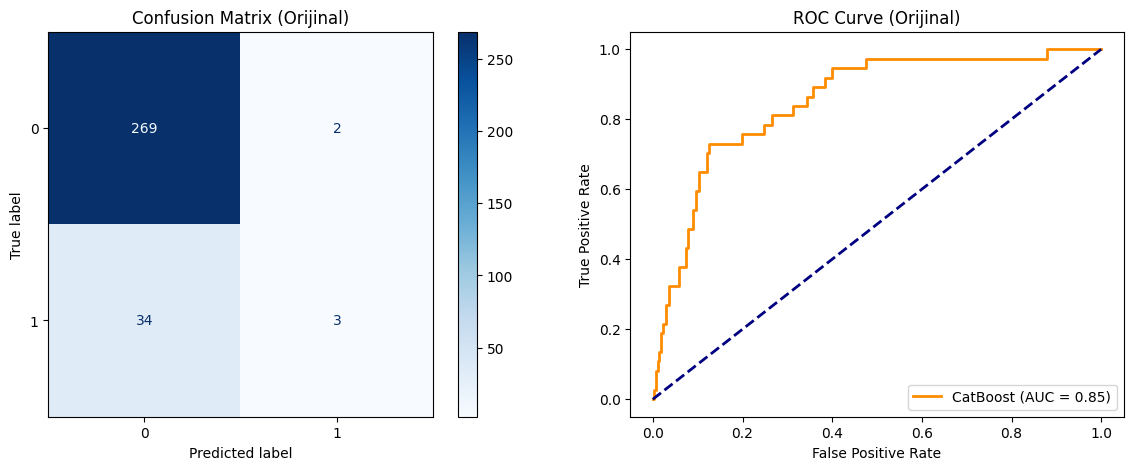

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix (Orijinal)')

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'CatBoost (AUC = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve (Orijinal)')
ax2.legend(loc="lower right")

plt.show()

In [41]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [42]:
x_test_final_scaled = scaler.transform(x_test_final)

In [43]:
best_model = CatBoostClassifier(verbose=0, random_state=42)
best_model.fit(x_scaled, y)

CatBoostClassifier(random_state=42, verbose=0)

In [44]:
final_probs = best_model.predict_proba(x_test_final_scaled)[:, 1]

In [45]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Attrition': final_probs
})

submission.to_csv('submission.csv', index=False)

In [46]:
submission

,id,Attrition
0,1677,0.125415
1,1678,0.033177
2,1679,0.021578
3,1680,0.042521
4,1681,0.541875
...,...,...
1114,2791,0.066958
1115,2792,0.003134
1116,2793,0.018081
1117,2794,0.008952


In [47]:
best_model.save_model("employee_catboost_model.cbm")

In [48]:
joblib.dump(scaler, "employee_scaler.pkl")

['employee_scaler.pkl']

In [49]:
joblib.dump(encoders, "employee_encoder.pkl")

['employee_encoder.pkl']